# IY030 – SimCLR + MLP vs SimCLR + SVM: TF @ Condition Classification

**Goal:** Replace the SVM linear probe from IY031 with a small MLP classifier trained on top
of the **frozen** SimCLR backbone embeddings, and benchmark the two head types.

The backbone is frozen throughout — this isolates the classifier as the only difference.

**Pipeline:**  
`SimCLR backbone (frozen) → embeddings (d_model-dim) → MLP (CE loss)`  
vs IY031's:  
`SimCLR backbone (frozen) → embeddings (d_model-dim) → RBF-SVM`

**Dataset / split / checkpoints:** identical to IY031 (6-class Nrg1/Rtg1 × glucose, exp 18446 excluded,
stratified 80/20, seed 42).

In [1]:
import re
import sys
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path
from functools import partial
from matplotlib.patches import Patch
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
from utils.embeddings import (
    load_simclr_model, encode_channel, parse_arch_from_name,
    make_checkpoint_short_label, make_unique_checkpoint_label,
)

RANDOM_STATE = 42
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FIXED_CLASSES = [
    "Nrg1 @ 0.01% glucose",
    "Nrg1 @ 0.1% glucose",
    "Nrg1 @ 2% glucose (mock/steady)",
    "Rtg1 @ 0.01% glucose",
    "Rtg1 @ 0.1% glucose",
    "Rtg1 @ 2% glucose (mock/steady)",
]

NORM_OVERRIDES = {
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model": "joint",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model": "global",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model": "joint",
}
make_short_label  = partial(make_checkpoint_short_label,  norm_overrides=NORM_OVERRIDES)
make_unique_label = partial(make_unique_checkpoint_label, norm_overrides=NORM_OVERRIDES)

IY030_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY030")
IY031_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY031")
IY008_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008")
EXP_DIR       = Path("/home/ianyang/stochastic_simulations/experiments")
SS_DATA_DIR   = IY008_DIR / "4_transformed_exp_time_series"
FULL_DATA_DIR = IY008_DIR / "5_FULL_transformed_exp_time_series"
META_PATH     = IY008_DIR / "old_data_metadata.csv"
META_COLS     = ["id", "group", "experiment"]
EXCLUDED_EXPS = {"18446"}
FILE_RE       = re.compile(r"^(\d+)_.*_group_(.+?)_(GFP|mCherry)_time_series$")
CKPT_DIRS     = ["EXP-26-IY017", "EXP-26-IY022", "EXP-26-IY023", "EXP-26-IY024"]

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif", "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")
print(f"Device: {DEVICE}")

Device: cuda


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Metadata & Data Loading (identical to IY031)

In [2]:
from utils.experimental_time_series import load_labelled_time_series_csvs
from utils.processing.pipeline import prepare_dataset

metadata = pd.read_csv(META_PATH)
metadata["exp_id"]   = metadata["exp_id"].astype(str)
metadata["group_id"] = metadata["group_id"].astype(str)
LABEL_LOOKUP = {
    (row.exp_id, row.group_id, row.channel): (row.tf, row.condition)
    for _, row in metadata.iterrows()
}

def load_dataset(data_dir: Path):
    return load_labelled_time_series_csvs(
        data_dir=data_dir, file_re=FILE_RE, label_lookup=LABEL_LOOKUP,
        meta_cols=META_COLS, excluded_exps=EXCLUDED_EXPS,
    )

ss_ts_raw,   ss_label_strs   = load_dataset(SS_DATA_DIR)
full_ts_raw, full_label_strs = load_dataset(FULL_DATA_DIR)

print("--- Steady-state ---")
ss   = prepare_dataset(ss_ts_raw,   ss_label_strs,   FIXED_CLASSES, "Steady-state", RANDOM_STATE)
print("--- Full ---")
full = prepare_dataset(full_ts_raw, full_label_strs, FIXED_CLASSES, "Full",         RANDOM_STATE)

  18360/1106/GFP       -> Mig2 @ 0.1% glucose                            (233 cells, 122 tp)
  18360/1106/mCherry   -> Mig1 @ 0.1% glucose                            (233 cells, 23 tp)
  18360/898/GFP       -> Msn2 @ 0.1% glucose                            (254 cells, 116 tp)
  18360/898/mCherry   -> Mig1 @ 0.1% glucose                            (254 cells, 24 tp)
  18360/900/GFP       -> Mig1 @ 0.1% glucose                            (243 cells, 63 tp)
  18360/900/mCherry   -> Msn2 @ 0.1% glucose                            (243 cells, 178 tp)
  18464/756/GFP       -> Sfp1 @ 2% glucose (mock/steady)                (209 cells, 201 tp)
  18464/756/mCherry   -> Msn2 @ 2% glucose (mock/steady)                (209 cells, 237 tp)
  18464/764/GFP       -> Sfp1 @ 2% glucose (mock/steady)                (202 cells, 178 tp)
  18464/764/mCherry   -> Dot6 @ 2% glucose (mock/steady)                (202 cells, 129 tp)
  18464/903/GFP       -> Dot6 @ 2% glucose (mock/steady)                (220 cell

## 2. Model Registry (identical to IY031)

In [3]:
EXP_COLOR_MAP = {
    "EXP-26-IY017": sns.color_palette("colorblind")[0],
    "EXP-26-IY022": sns.color_palette("colorblind")[1],
    "EXP-26-IY023": sns.color_palette("colorblind")[2],
    "EXP-26-IY024": sns.color_palette("colorblind")[4],
}

MODEL_REGISTRY = []
for _d in CKPT_DIRS:
    for p in sorted((EXP_DIR / _d).glob("*.pth")):
        MODEL_REGISTRY.append({
            "path":        p,
            "short_label": make_short_label(p),
            "label":       make_unique_label(p, len(MODEL_REGISTRY)),
            "experiment":  _d,
        })

print(f"Found {len(MODEL_REGISTRY)} checkpoints")

Found 34 checkpoints


## 3. MLP Head

A small 2-hidden-layer MLP trained on the frozen SimCLR backbone embeddings.
Architecture: `d_model → 64 → 32 → n_classes` with BatchNorm, ReLU, Dropout.

BatchNorm is included because the embedding magnitudes vary across checkpoints;
it normalises each hidden layer's input without needing a separate StandardScaler.

In [ ]:
class EmbeddingMLP(nn.Module):
    """2-hidden-layer MLP for classification of pre-computed embeddings."""
    def __init__(self, in_dim: int, n_classes: int,
                 hidden: tuple = (64, 32), dropout: float = 0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)  # raw logits


def train_mlp(
    Z_train: np.ndarray,
    y_train: np.ndarray,
    Z_test:  np.ndarray,
    y_test:  np.ndarray,
    n_classes: int,
    *,
    hidden: tuple = (64, 32),
    dropout: float = 0.3,
    n_epochs: int = 300,
    batch_size: int = 32,
    lr: float = 1e-3,
    weight_decay: float = 1e-3,
    patience: int = 40,
    val_frac: float = 0.15,
    device=DEVICE,
    seed: int = RANDOM_STATE,
) -> dict:
    """Train EmbeddingMLP on pre-computed embeddings with early stopping.

    - 15% of Z_train held out as val for early stopping (no data leakage).
    - Best val-accuracy checkpoint is restored before test evaluation.
    Returns dict: test_acc, best_val_acc, y_pred.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    # val split for early stopping
    idx = np.arange(len(y_train))
    idx_tr, idx_val = train_test_split(idx, test_size=val_frac,
                                       stratify=y_train, random_state=seed)
    Ztr, ytr = Z_train[idx_tr], y_train[idx_tr]
    Zva, yva = Z_train[idx_val], y_train[idx_val]

    def to_loader(Z, y, shuffle):
        Zt = torch.from_numpy(Z).float()
        yt = torch.from_numpy(y).long()
        return DataLoader(TensorDataset(Zt, yt), batch_size=batch_size,
                          shuffle=shuffle, drop_last=False)

    tr_loader  = to_loader(Ztr, ytr, shuffle=True)
    val_loader = to_loader(Zva, yva, shuffle=False)
    te_loader  = to_loader(Z_test, y_test, shuffle=False)

    model = EmbeddingMLP(Z_train.shape[1], n_classes,
                         hidden=hidden, dropout=dropout).to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    crit  = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    best_state   = None
    no_improve   = 0

    for _ in range(n_epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()
        sched.step()

        model.eval()
        pv = []
        with torch.no_grad():
            for xb, _ in val_loader:
                pv.append(model(xb.to(device)).argmax(1).cpu().numpy())
        val_acc = accuracy_score(yva, np.concatenate(pv))

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = copy.deepcopy(model.state_dict())
            no_improve   = 0
        else:
            no_improve  += 1
        if no_improve >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    pt = []
    with torch.no_grad():
        for xb, _ in te_loader:
            pt.append(model(xb.to(device)).argmax(1).cpu().numpy())
    y_pred = np.concatenate(pt)

    return {
        "test_acc":     accuracy_score(y_test, y_pred),
        "best_val_acc": best_val_acc,
        "y_pred":       y_pred,
    }

## 4. Run: SimCLR + MLP vs SimCLR + SVM

For every checkpoint: encode with frozen backbone → run SVM (IY031 baseline) → run MLP.

In [5]:
def run_simclr_svm(Z_tr, Z_te, y_tr, y_te):
    """StandardScale → RBF-SVM; mirrors IY031 exactly."""
    scaler = StandardScaler()
    Z_tr_sc = scaler.fit_transform(Z_tr)
    Z_te_sc = scaler.transform(Z_te)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
    clf.fit(Z_tr_sc, y_tr)
    y_pred = clf.predict(Z_te_sc)
    return accuracy_score(y_te, y_pred), y_pred


def run_all(d: dict, dataset_tag: str, csv_tag: str):
    """Evaluate every checkpoint with both SVM and MLP heads."""
    n_cls  = len(d["class_names"])
    chance = 1.0 / n_cls
    rows, preds = [], {}

    print(f"\n{'='*70}")
    print(f"{dataset_tag} ({n_cls} classes, chance={chance:.4f})")
    print(f"{'='*70}")
    print(f"  {'checkpoint':<52s}  {'SVM':>6s}  {'MLP':>6s}  {'ΔMLP-SVM':>9s}")

    for row in MODEL_REGISTRY:
        ckpt  = row["path"]
        label = row["label"]
        try:
            model  = load_simclr_model(ckpt, DEVICE)
            Z_tr   = encode_channel(model, d["X_train"], DEVICE)
            Z_te   = encode_channel(model, d["X_test"],  DEVICE)

            svm_acc, svm_pred = run_simclr_svm(Z_tr, Z_te, d["y_train"], d["y_test"])
            mlp_res           = train_mlp(Z_tr, d["y_train"], Z_te, d["y_test"], n_cls)
            mlp_acc           = mlp_res["test_acc"]
            delta             = mlp_acc - svm_acc

            print(f"  {label:<52s}  {svm_acc:.4f}  {mlp_acc:.4f}  {delta:+.4f}")
            preds[str(ckpt)] = {"svm": svm_pred, "mlp": mlp_res["y_pred"]}
            rows.append({
                "label":      label,
                "short_label": row["short_label"],
                "experiment": row["experiment"],
                "checkpoint": str(ckpt),
                "svm_acc":    svm_acc,
                "mlp_acc":    mlp_acc,
                "delta":      delta,
                "status":     "ok",
            })
        except Exception as exc:
            print(f"  {label:<52s}  FAILED: {exc}")
            rows.append({"label": label, "short_label": row["short_label"],
                         "experiment": row["experiment"],
                         "checkpoint": str(ckpt),
                         "svm_acc": np.nan, "mlp_acc": np.nan,
                         "delta": np.nan, "status": "failed"})

    df = (pd.DataFrame(rows)
            .sort_values("mlp_acc", ascending=False, na_position="last")
            .reset_index(drop=True))
    df.to_csv(IY030_DIR / f"IY030_{csv_tag}_svm_vs_mlp.csv", index=False)
    print(f"\nSaved: IY030_{csv_tag}_svm_vs_mlp.csv")
    return df, preds


ss_df,   ss_preds   = run_all(ss,   "Steady-state", "ss")
full_df, full_preds = run_all(full, "Full",          "full")


Steady-state (6 classes, chance=0.1667)
  checkpoint                                               SVM     MLP   ΔMLP-SVM


  IY017-inst b100 D128 #00                              0.6383  0.6170  -0.0213


  IY017-inst b100 D128 #01                              0.5532  0.5532  +0.0000


  IY017-inst b1024 D16 164413                           0.6064  0.6809  +0.0745


  IY017-inst b1024 D16 061239                           0.6277  0.6383  +0.0106


...

  IY023-global b64 D16 130449                           0.7128  0.7660  +0.0532


  IY023-batch b64 D8 120151                             0.7553  0.7553  +0.0000


  IY024-batch b64 D16 122627                            0.7979  0.7766  -0.0213


  IY024-batch b64 D16 210002                            0.7447  0.7872  +0.0426


  IY024-batch b64 D8 203126                             0.7340  0.7660  +0.0319

Saved: IY030_full_svm_vs_mlp.csv


## 5. Results: Bar Charts (SVM vs MLP per checkpoint)

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY030/IY030_ss_svm_vs_mlp.png


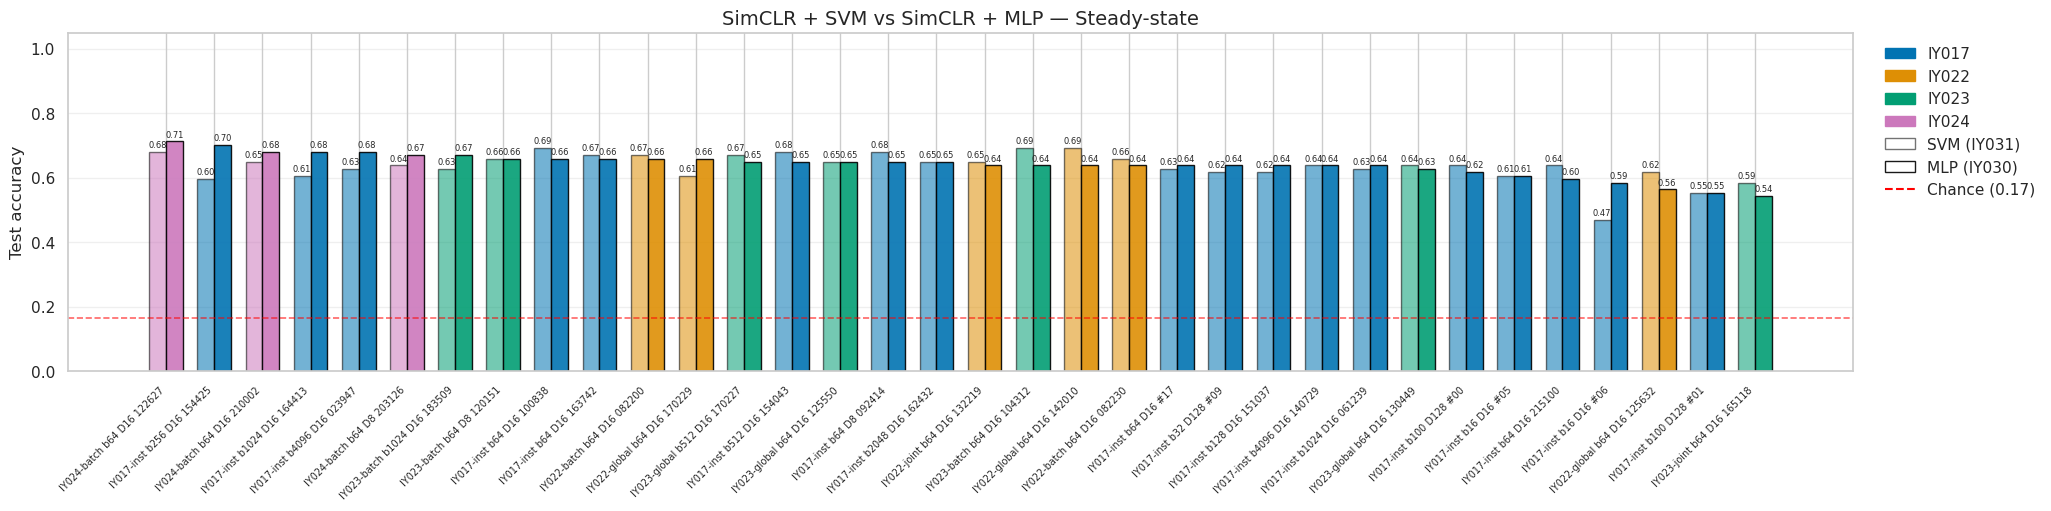

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY030/IY030_full_svm_vs_mlp.png


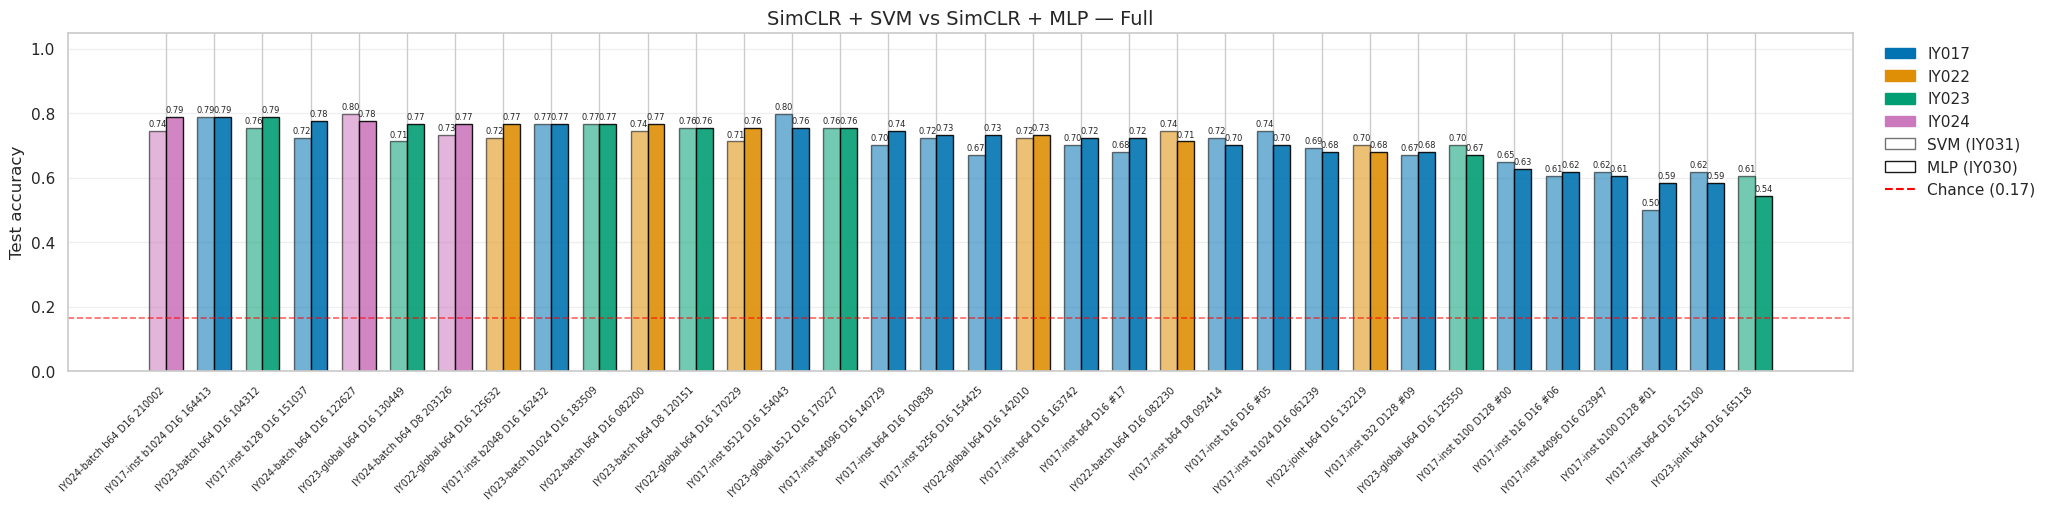

In [6]:
def plot_svm_vs_mlp(df, d, dataset_tag, fig_path):
    """Side-by-side SVM/MLP bars per checkpoint, colour-coded by experiment."""
    valid  = df[df["status"] == "ok"].copy()
    n      = len(valid)
    chance = 1.0 / len(d["class_names"])
    x      = np.arange(n)
    w      = 0.35
    pal    = sns.color_palette("colorblind")

    fig, ax = plt.subplots(figsize=(max(14, n * 0.6), 5), constrained_layout=True)

    bar_colors = [EXP_COLOR_MAP.get(exp, (0.5,)*3) for exp in valid["experiment"]]

    b1 = ax.bar(x - w/2, valid["svm_acc"], width=w,
                color=bar_colors, alpha=0.55, edgecolor="black", label="SVM (IY031)")
    b2 = ax.bar(x + w/2, valid["mlp_acc"], width=w,
                color=bar_colors, alpha=0.90, edgecolor="black", label="MLP (IY030)")

    for bar, v in zip(b1, valid["svm_acc"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{v:.2f}", ha="center", va="bottom", fontsize=6)
    for bar, v in zip(b2, valid["mlp_acc"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{v:.2f}", ha="center", va="bottom", fontsize=6)

    ax.axhline(chance, color="red", ls="--", lw=1.2, alpha=0.6,
               label=f"Chance ({chance:.2f})")
    ax.set_xticks(x)
    ax.set_xticklabels(valid["label"], rotation=45, ha="right", fontsize=7)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Test accuracy")
    ax.set_title(f"SimCLR + SVM vs SimCLR + MLP — {dataset_tag}", fontsize=14)
    ax.grid(axis="y", alpha=0.3)

    exp_handles = [
        Patch(color=EXP_COLOR_MAP.get(e, (0.5,)*3), label=e.replace("EXP-26-", ""))
        for e in CKPT_DIRS
    ]
    style_handles = [
        Patch(facecolor="white", edgecolor="black", alpha=0.55, label="SVM (IY031)"),
        Patch(facecolor="white", edgecolor="black", alpha=0.90, label="MLP (IY030)"),
        plt.Line2D([0],[0], color="red", ls="--", label=f"Chance ({chance:.2f})"),
    ]
    ax.legend(handles=exp_handles + style_handles,
              bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()


plot_svm_vs_mlp(ss_df,   ss,   "Steady-state",
                IY030_DIR / "IY030_ss_svm_vs_mlp.png")
plot_svm_vs_mlp(full_df, full, "Full",
                IY030_DIR / "IY030_full_svm_vs_mlp.png")

## 6. Summary: Best SVM vs Best MLP

SUMMARY — best accuracy across all checkpoints
Method                      SS      Full
SimCLR + SVM            0.6915    0.7979
SimCLR + MLP            0.7128    0.7872
Chance                  0.1667    0.1667
Saved: IY030_summary_svm_vs_mlp.png


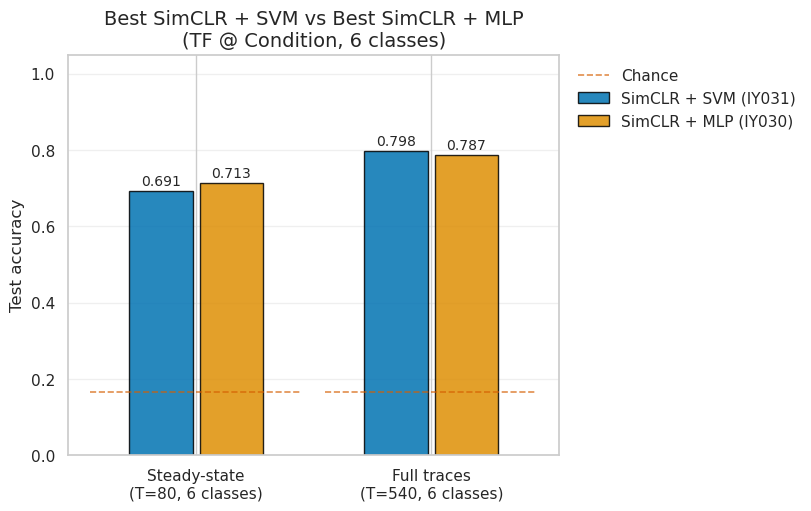

In [7]:
def valid(df):
    return df[df["status"] == "ok"]

ss_best_svm   = valid(ss_df)["svm_acc"].max()
ss_best_mlp   = valid(ss_df)["mlp_acc"].max()
full_best_svm = valid(full_df)["svm_acc"].max()
full_best_mlp = valid(full_df)["mlp_acc"].max()
ss_chance     = 1.0 / len(ss["class_names"])
full_chance   = 1.0 / len(full["class_names"])

print("SUMMARY — best accuracy across all checkpoints")
print(f"{'Method':<20s}  {'SS':>8s}  {'Full':>8s}")
print(f"{'SimCLR + SVM':20s}  {ss_best_svm:8.4f}  {full_best_svm:8.4f}")
print(f"{'SimCLR + MLP':20s}  {ss_best_mlp:8.4f}  {full_best_mlp:8.4f}")
print(f"{'Chance':20s}  {ss_chance:8.4f}  {full_chance:8.4f}")

pal   = sns.color_palette("colorblind")
x     = np.arange(2)
width = 0.3
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
for i, (method, sv, fv) in enumerate([
    ("SimCLR + SVM (IY031)", ss_best_svm,  full_best_svm),
    ("SimCLR + MLP (IY030)", ss_best_mlp,  full_best_mlp),
]):
    bars = ax.bar(x + (i - 0.5) * width, [sv, fv], width=width * 0.9,
                  label=method, color=pal[i], alpha=0.85, edgecolor="black")
    for bar, v in zip(bars, [sv, fv]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{v:.3f}", ha="center", va="bottom", fontsize=10)

ax.plot(x[0] + np.array([-0.45, 0.45]), [ss_chance]*2,   "r--", lw=1.2, alpha=0.7, label="Chance")
ax.plot(x[1] + np.array([-0.45, 0.45]), [full_chance]*2, "r--", lw=1.2, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f"Steady-state\n(T=80, {len(ss['class_names'])} classes)",
                    f"Full traces\n(T=540, {len(full['class_names'])} classes)"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test accuracy")
ax.set_title("Best SimCLR + SVM vs Best SimCLR + MLP\n"
             "(TF @ Condition, 6 classes)", fontsize=14)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
ax.grid(axis="y", alpha=0.3)
fig.savefig(IY030_DIR / "IY030_summary_svm_vs_mlp.png", dpi=150, bbox_inches="tight")
print("Saved: IY030_summary_svm_vs_mlp.png")
plt.show()

## 7. Delta Plot: MLP − SVM per Checkpoint

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY030/IY030_ss_delta.png


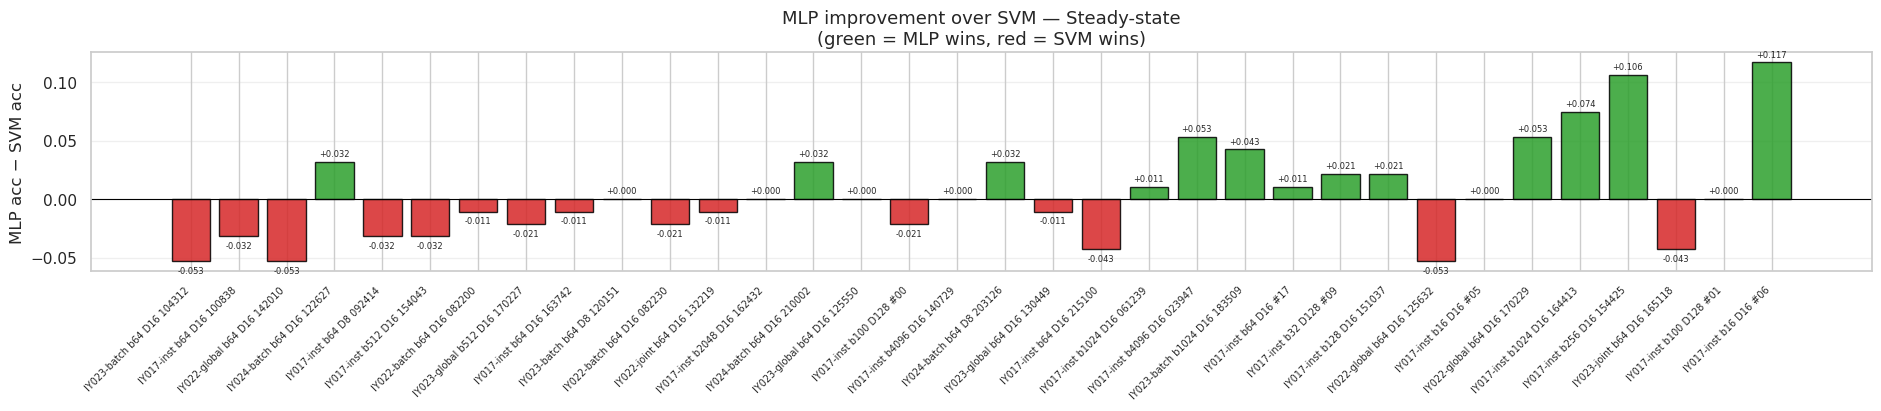

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY030/IY030_full_delta.png


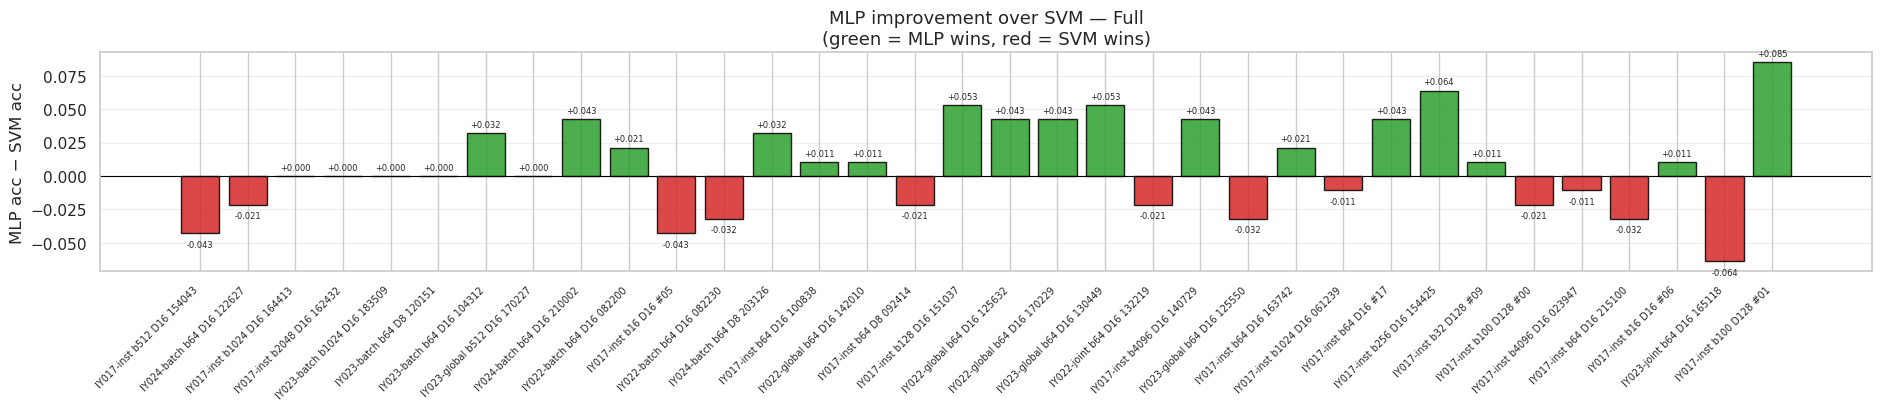

In [8]:
def plot_delta(df, dataset_tag, fig_path):
    """Bar chart of MLP acc − SVM acc per checkpoint; green = MLP wins."""
    v = df[df["status"] == "ok"].copy()
    # sort by SVM acc (same ordering as IY031) to make comparison easy
    v = v.sort_values("svm_acc", ascending=False).reset_index(drop=True)
    colors = ["#2ca02c" if d >= 0 else "#d62728" for d in v["delta"]]

    fig, ax = plt.subplots(figsize=(max(14, len(v) * 0.55), 4), constrained_layout=True)
    bars = ax.bar(range(len(v)), v["delta"], color=colors, edgecolor="black", alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    for bar, val in zip(bars, v["delta"]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.003 if val >= 0 else -0.012),
                f"{val:+.3f}", ha="center", va="bottom", fontsize=6)
    ax.set_xticks(range(len(v)))
    ax.set_xticklabels(v["label"], rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("MLP acc − SVM acc")
    ax.set_title(f"MLP improvement over SVM — {dataset_tag}\n"
                 "(green = MLP wins, red = SVM wins)", fontsize=13)
    ax.grid(axis="y", alpha=0.3)
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()


plot_delta(ss_df,   "Steady-state", IY030_DIR / "IY030_ss_delta.png")
plot_delta(full_df, "Full",         IY030_DIR / "IY030_full_delta.png")

## 8. Confusion Matrices — Best Checkpoint per Method × Dataset

Saved: IY030_confusion_matrices.png


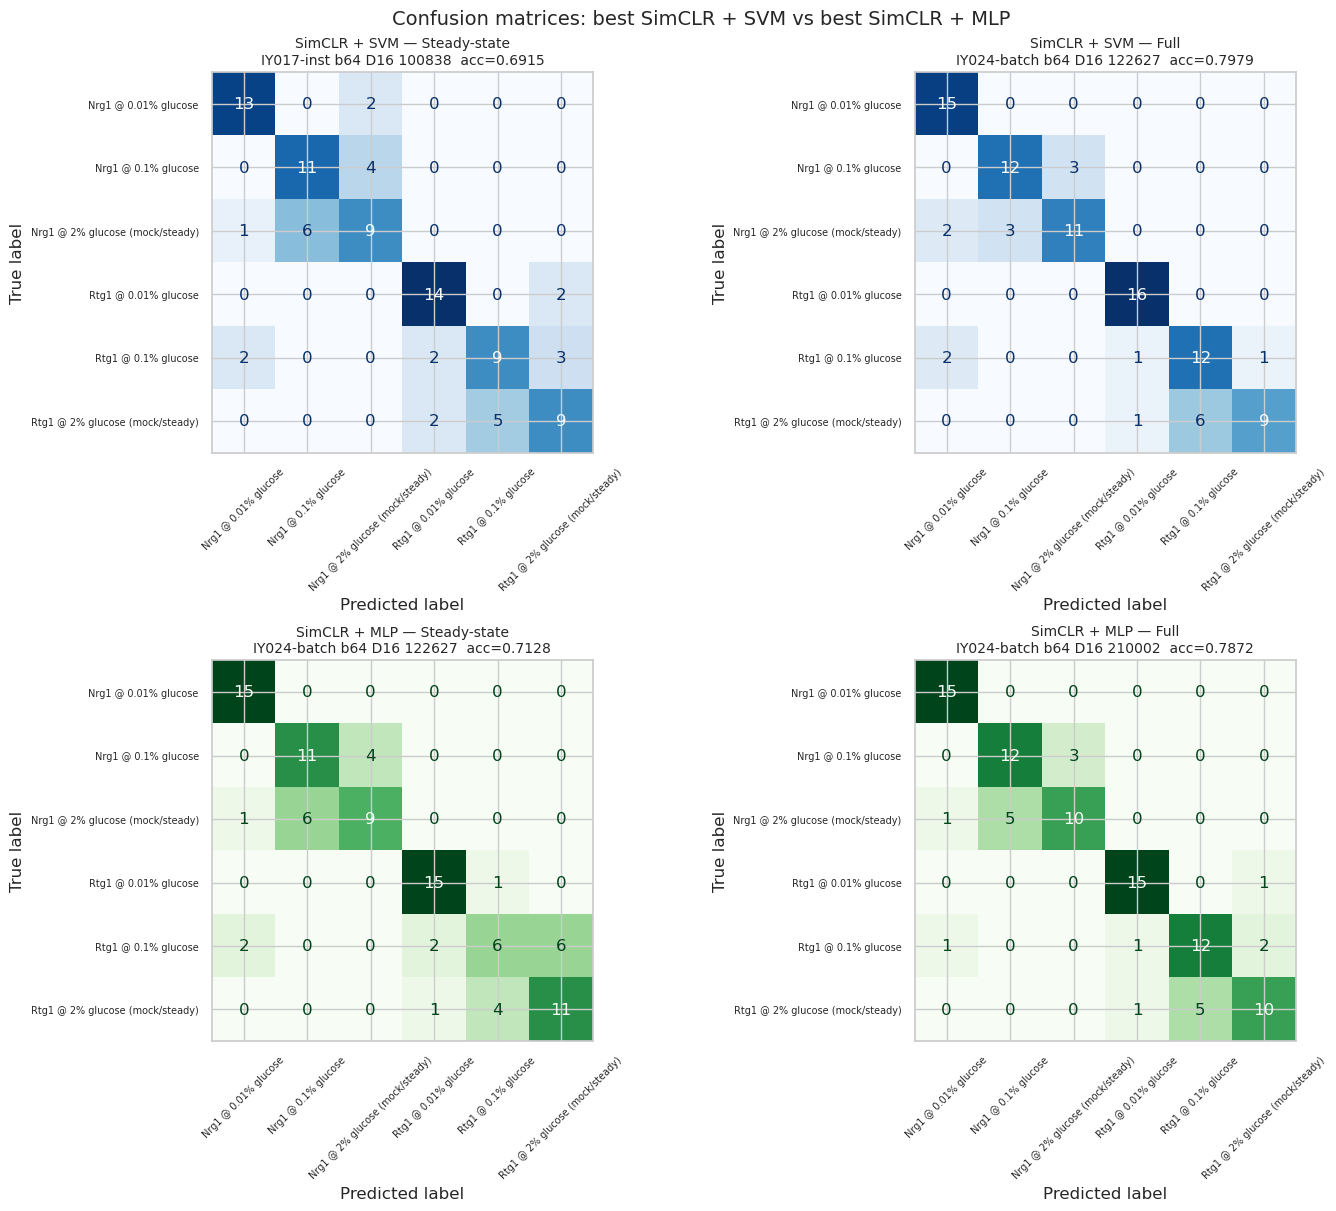

In [9]:
def best_preds(df, preds_dict, head):
    """Return (y_pred, label, acc) for the checkpoint with highest <head>_acc."""
    v   = df[df["status"] == "ok"]
    row = v.loc[v[f"{head}_acc"].idxmax()]
    return preds_dict[row["checkpoint"]][head], row["label"], row[f"{head}_acc"]


fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
entries = [
    (axes[0, 0], ss,   *best_preds(ss_df,   ss_preds,   "svm"), "SVM",  "Steady-state", "Blues"),
    (axes[0, 1], full, *best_preds(full_df, full_preds, "svm"), "SVM",  "Full",         "Blues"),
    (axes[1, 0], ss,   *best_preds(ss_df,   ss_preds,   "mlp"), "MLP",  "Steady-state", "Greens"),
    (axes[1, 1], full, *best_preds(full_df, full_preds, "mlp"), "MLP",  "Full",         "Greens"),
]
for ax, d, y_pred, ckpt_label, acc, head, dataset_tag, cmap in entries:
    ConfusionMatrixDisplay.from_predictions(
        d["y_test"], y_pred,
        display_labels=d["class_names"],
        ax=ax, colorbar=False, cmap=cmap,
    )
    ax.set_title(f"SimCLR + {head} — {dataset_tag}\n{ckpt_label}  acc={acc:.4f}",
                 fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Confusion matrices: best SimCLR + SVM vs best SimCLR + MLP", fontsize=14)
fig.savefig(IY030_DIR / "IY030_confusion_matrices.png", dpi=150, bbox_inches="tight")
print("Saved: IY030_confusion_matrices.png")
plt.show()

## 9. Detailed Classification Reports — Best Checkpoint

In [10]:
for dataset_tag, d, df, preds_dict in [
    ("Steady-state", ss,   ss_df,   ss_preds),
    ("Full",         full, full_df, full_preds),
]:
    print(f"\n{'='*60}\n{dataset_tag}\n{'='*60}")
    for head in ["svm", "mlp"]:
        y_pred, lbl, acc = best_preds(df, preds_dict, head)
        print(f"\n--- Best SimCLR + {head.upper()} ({lbl}, acc={acc:.4f}) ---")
        print(classification_report(d["y_test"], y_pred,
                                    target_names=d["class_names"]))


Steady-state

--- Best SimCLR + SVM (IY017-inst b64 D16 100838, acc=0.6915) ---
                                 precision    recall  f1-score   support

           Nrg1 @ 0.01% glucose       0.81      0.87      0.84        15
            Nrg1 @ 0.1% glucose       0.65      0.73      0.69        15
Nrg1 @ 2% glucose (mock/steady)       0.60      0.56      0.58        16
           Rtg1 @ 0.01% glucose       0.78      0.88      0.82        16
            Rtg1 @ 0.1% glucose       0.64      0.56      0.60        16
Rtg1 @ 2% glucose (mock/steady)       0.64      0.56      0.60        16

                       accuracy                           0.69        94
                      macro avg       0.69      0.69      0.69        94
                   weighted avg       0.69      0.69      0.69        94


--- Best SimCLR + MLP (IY024-batch b64 D16 122627, acc=0.7128) ---
                                 precision    recall  f1-score   support

           Nrg1 @ 0.01% glucose       0.83  